# NB01 — Data Assembly & Response Variable (v2, `nmdc.results`)

**Project:** `euk_in_prok_correlates`. Per **v2 of the research plan**, the response is built from the native
`nmdc.results.{gottcha2,kraken2,centrifuge}_classification_report` tables (more recent, more euk-positive), at
the unit of one **NMDC ReadbasedAnalysis run** (`workflow_run_id`) — the three classifiers share this id, and
run-level analysis avoids pooling pseudo-replication. Heavy Spark aggregation is in `src/build_analysis_table.py`;
this notebook loads the frozen table, defines the response, cleans predictors, and characterises the distribution.
See `data/01_data_landscape.md` for why NMDC is few-study and `memories/pitfalls.md` for classifier caveats.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
DATA=Path('../data'); FIG=Path('../figures'); FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi':110,'savefig.bbox':'tight','axes.grid':True,'grid.alpha':.3})
at = pd.read_csv(DATA/'analysis_table.csv')
print('runs:', len(at), '| studies:', at.study_id.nunique())
at.head(3)

runs: 2760 | studies: 9


,sample_id,biosample_id,study_id,has_pooling,has_extraction,gott_euk_frac,gott_plastid_frac,gott_euk_nonplastid_frac,krak_euk_frac,cent_euk_frac,...,ecosystem,ecosystem_category,ecosystem_type,ecosystem_subtype,samp_collec_device,depth_m,host_taxid_term_name,host_name,geo_loc,platform
0,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,nmdc:wfrbt-11-0083q358.1,nmdc:bsm-12-hb3gxc87,nmdc:sty-11-pzmd0x14,0.0,1.0,0.429038,0.429038,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"USA: Texas, Pringle Creek",NaN
2,nmdc:wfrbt-11-00h2wj84.1,nmdc:bsm-11-7asn9342,nmdc:sty-11-r2h77870,0.0,0.0,0.000000,0.000000,0.0,0.0,NaN,...,Environmental,Terrestrial,Soil,Botanical garden,NaN,0.1,NaN,NaN,USA: Oregon,novaseq_6000


## Response variables
- **`gott_euk_frac`** (primary): relative eukaryotic abundance (Eukaryota + plastid), GOTTCHA2 superkingdom.
- **`gott_plastid_frac`**: plastid-only = plant/algal chloroplast (the *photosynthetic* source).
- **`gott_euk_nonplastid_frac`**: non-plastid Eukaryota (protist/fungal).
- `krak_euk_frac`, `cent_euk_frac`: Kraken2 / Centrifuge Eukaryota — retained only as controls; both ≈ 0 at
  domain rank because their NMDC reference DBs are prokaryote-restricted (host/Metazoa signal is negligible here).

In [2]:
resp=['gott_euk_frac','gott_plastid_frac','gott_euk_nonplastid_frac','krak_euk_frac','cent_euk_frac']
display(at[resp].describe().round(4))
det=(at[resp]>0).mean().round(3)
print('\nDetection rate (frac runs >0):'); print(det.to_string())
print('\nKraken/Centrifuge euk ~0 -> no usable host signal in nmdc.results at domain rank; GOTTCHA is the response.')

,gott_euk_frac,gott_plastid_frac,gott_euk_nonplastid_frac,krak_euk_frac,cent_euk_frac
count,2760.0000,2760.0000,2760.0000,2759.0,0.0
mean,0.1333,0.1129,0.0204,0.0,NaN
std,0.2295,0.2284,0.0637,0.0,NaN
min,0.0000,0.0000,0.0000,0.0,NaN
25%,0.0009,0.0000,0.0000,0.0,NaN
50%,0.0271,0.0058,0.0000,0.0,NaN
75%,0.1405,0.0800,0.0031,0.0,NaN
max,1.0000,1.0000,1.0000,0.0,NaN



Detection rate (frac runs >0):
gott_euk_frac               0.771
gott_plastid_frac           0.647
gott_euk_nonplastid_frac    0.292
krak_euk_frac               0.000
cent_euk_frac               0.000

Kraken/Centrifuge euk ~0 -> no usable host signal in nmdc.results at domain rank; GOTTCHA is the response.


## Predictor cleaning, matrix grouping, within-study fields

In [3]:
at['matrix']=at['ecosystem_category'].fillna('Unknown')
at['ecosystem_type']=at['ecosystem_type'].fillna('Unknown')
at['ecosystem_subtype']=at['ecosystem_subtype'].fillna('Unknown')
at['env_medium']=at['env_medium_term_name'].fillna('Unknown')
at['env_local']=at['env_local_scale_term_name'].fillna('Unknown')
at['platform']=at['platform'].fillna('Unknown')
at['host_assoc']=at['host_name'].notna()|at['host_taxid_term_name'].notna()
at['euk_detect']=(at['gott_euk_frac']>0).astype(int)
eps=1e-4
at['euk_logit']=np.log((at['gott_euk_frac']+eps)/(1-at['gott_euk_frac']+eps))
print('matrix counts:'); print(at['matrix'].value_counts().to_string())
print('\nrun-level euk detection rate:', round(at['euk_detect'].mean(),3),
      '| median euk:', round(at['gott_euk_frac'].median(),4))
print('pooled runs:', int(at['has_pooling'].fillna(0).sum()), '/', len(at))

matrix counts:
matrix
Unknown        1002
Terrestrial     928
Aquatic         622
Plants          208

run-level euk detection rate: 0.771 | median euk: 0.0271
pooled runs: 1067 / 2760


## Figure 1 — Response distribution & eukaryotic source split

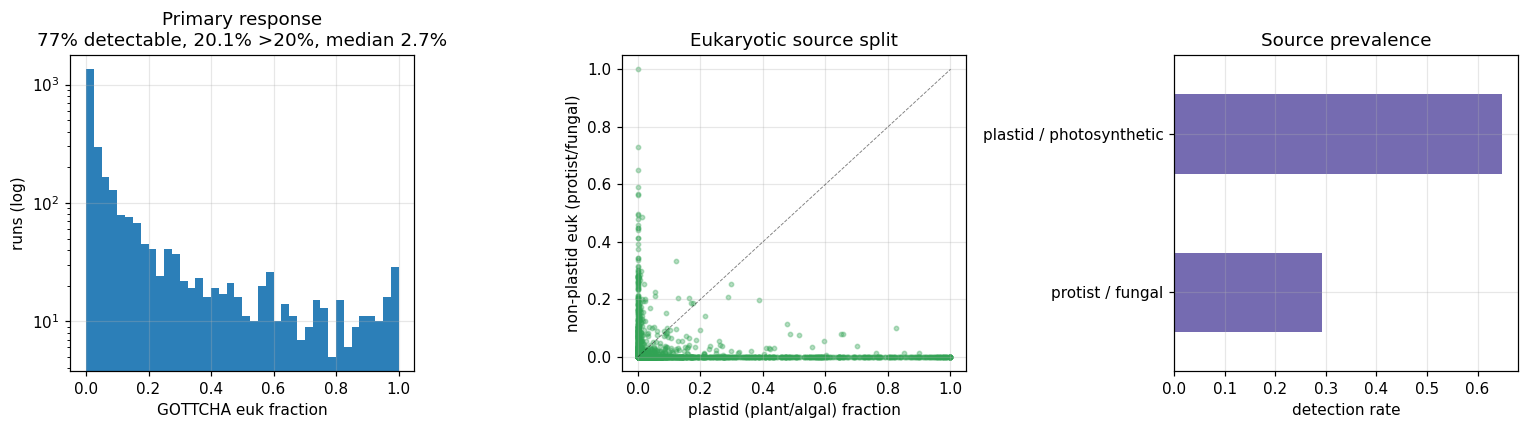

saved fig01


In [4]:
fig,axes=plt.subplots(1,3,figsize=(14,4))
ax=axes[0]; ax.hist(at['gott_euk_frac'],bins=40,color='#2c7fb8'); ax.set_yscale('log')
ax.set_xlabel('GOTTCHA euk fraction'); ax.set_ylabel('runs (log)')
ax.set_title(f"Primary response\n{at['euk_detect'].mean()*100:.0f}% detectable, "
             f"{(at['gott_euk_frac']>0.2).mean()*100:.1f}% >20%, median {at['gott_euk_frac'].median()*100:.1f}%")
ax=axes[1]; d=at[at['gott_euk_frac']>0]
ax.scatter(d['gott_plastid_frac'],d['gott_euk_nonplastid_frac'],s=8,alpha=.35,color='#31a354')
ax.plot([0,1],[0,1],'k--',lw=.6,alpha=.5)
ax.set_xlabel('plastid (plant/algal) fraction'); ax.set_ylabel('non-plastid euk (protist/fungal)')
ax.set_title('Eukaryotic source split')
ax=axes[2]
srcs=pd.Series({'plastid / photosynthetic':(at['gott_plastid_frac']>0).mean(),
               'protist / fungal':(at['gott_euk_nonplastid_frac']>0).mean()}).sort_values()
srcs.plot.barh(ax=ax,color='#756bb1'); ax.set_xlabel('detection rate'); ax.set_title('Source prevalence')
plt.tight_layout(); plt.savefig(FIG/'fig01_euk_distributions.png'); plt.show(); print('saved fig01')

## Eukaryotic signal is plastid-dominated (source composition)

In [5]:
frac_plastid = (at.loc[at['gott_euk_frac']>0,'gott_plastid_frac'] /
                at.loc[at['gott_euk_frac']>0,'gott_euk_frac']).median()
print(f'Among detectable runs, plastid is a median {frac_plastid*100:.0f}% of the eukaryotic signal.')
print('=> eukaryotic contamination in NMDC metagenomes is overwhelmingly photosynthetic (plant/algal chloroplast).')

Among detectable runs, plastid is a median 100% of the eukaryotic signal.
=> eukaryotic contamination in NMDC metagenomes is overwhelmingly photosynthetic (plant/algal chloroplast).


## Save cleaned analysis table

In [6]:
keep=['sample_id','biosample_id','study_id','has_pooling','has_extraction',
      'gott_euk_frac','gott_plastid_frac','gott_euk_nonplastid_frac','euk_detect','euk_logit',
      'matrix','ecosystem_type','ecosystem_subtype','env_medium','env_local','samp_collec_device',
      'depth_m','platform','host_assoc','geo_loc']
clean=at[keep].copy(); clean.to_csv(DATA/'analysis_clean.csv',index=False)
print('wrote data/analysis_clean.csv', clean.shape)

wrote data/analysis_clean.csv (2760, 20)


## NB01 takeaways
- 2,760 ReadbasedAnalysis runs (9 studies) with a GOTTCHA euk fraction; response strongly zero-inflated but
  richer than the earlier snapshot (median euk ~2.7%, 13% mean).
- Eukaryotic signal is **overwhelmingly plastid** (photosynthetic: plant/algal chloroplast); protist/fungal is
  secondary; host/Metazoa (Kraken) is negligible in NMDC.
- `env_local_scale` is 100% covered → enables the within-study test in NB04.
- Cleaned table saved for NB02 (univariate), NB03 (cross-study model), NB04 (within-study).